# 02 - ASVC Implementation and Verification

Tests the three ASVC improvement modules:
1. Adaptive parameter selection
2. Spectral connectivity analysis
3. Density-aware BSV assignment

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from src.svc import SVC
from src.asvc import ASVC
from src.utils import standardize, generate_synthetic_datasets, load_uci_iris, clustering_metrics
from src.parameter_selection import estimate_q_range, compute_C_from_nu, adaptive_q_search

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (10, 6), "font.size": 12})
print("Ready.")

Ready.


## 2.1 Adaptive Parameter Selection

In [2]:
datasets = generate_synthetic_datasets()
for name in ["TwoMoons", "ConcentricCircles", "ThreeBlobs"]:
    X, y = datasets[name]
    N = X.shape[0]
    q_min, q_max = estimate_q_range(X)
    C = compute_C_from_nu(nu=0.02, N=N)
    best_q, _ = adaptive_q_search(X, nu=0.02, n_trials=10)
    print(f"{name}: q_range=[{q_min:.4f}, {q_max:.4f}], C(nu=0.02)={C:.4f}, best_q={best_q:.4f}")

TwoMoons: q_range=[0.4352, 1740.8088], C(nu=0.02)=0.1667, best_q=17.3623
ConcentricCircles: q_range=[0.3303, 1321.3372], C(nu=0.02)=0.1667, best_q=16.0026
ThreeBlobs: q_range=[2.0173, 8069.0747], C(nu=0.02)=0.1667, best_q=36.1393


## 2.2 ASVC vs SVC on Two Moons

In [3]:
X, y_true = datasets["TwoMoons"]
svc = SVC(q=4.5, C=1.0, n_sample_points=30)
t0 = time.time(); svc.fit(X); t_svc = time.time() - t0
asvc = ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42)
t0 = time.time(); asvc.fit(X); t_asvc = time.time() - t0
print(f"SVC  ARI={clustering_metrics(y_true, svc.labels_)['ARI']:.4f}, time={t_svc:.2f}s")
print(f"ASVC ARI={clustering_metrics(y_true, asvc.labels_)['ARI']:.4f}, time={t_asvc:.2f}s")
print(f"ASVC auto: q={asvc.q_used_:.4f}, C={asvc.C_used_:.4f}")


SVC  ARI=1.0000, time=3.84s
ASVC ARI=0.4284, time=74.85s
ASVC auto: q=17.3623, C=0.1667


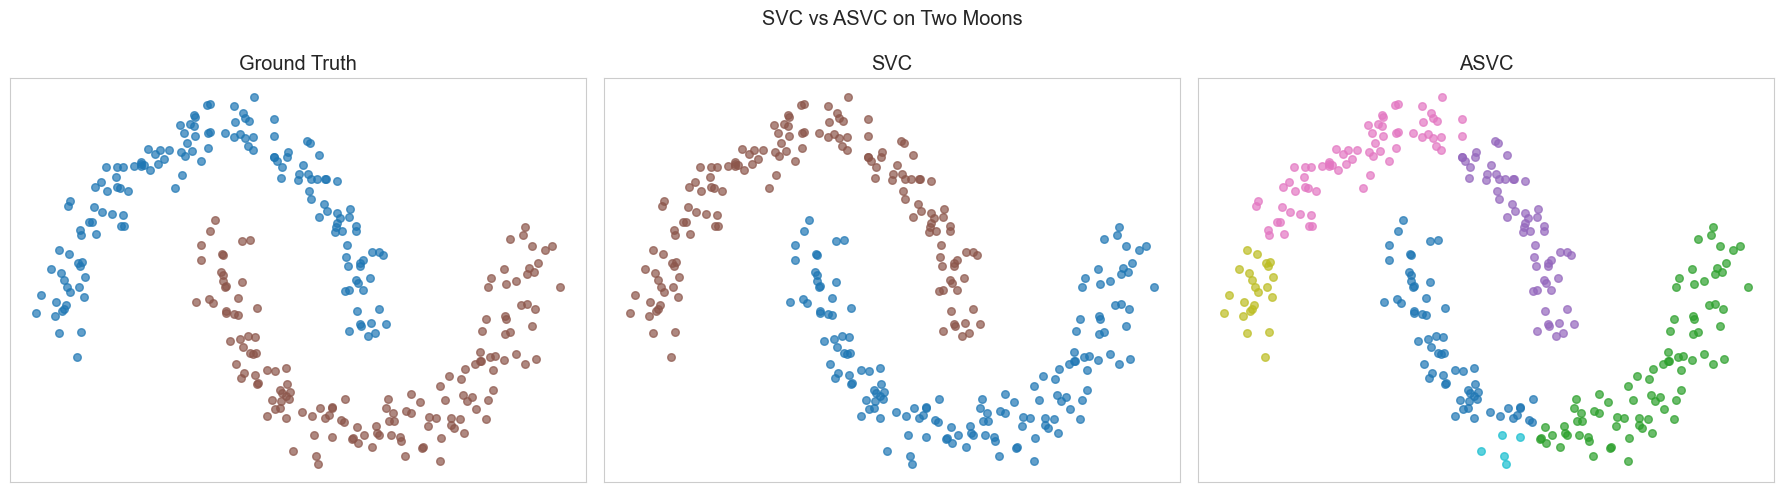

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, title, labels in zip(axes, ["Ground Truth", "SVC", "ASVC"], [y_true, svc.labels_, asvc.labels_]):
    ul = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(ul), 3)))
    for i, lab in enumerate(ul):
        mask = labels == lab
        ax.scatter(X[mask,0], X[mask,1], c=[colors[i]], s=30, alpha=0.7)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("SVC vs ASVC on Two Moons"); plt.tight_layout(); plt.show()

## 2.3 ASVC on Concentric Circles

In [5]:
Xc, yc = datasets["ConcentricCircles"]
asvc_c = ASVC(nu=0.02, q="auto", q_search_n_trials=10, random_state=42).fit(Xc)
svc_c = SVC(q=5.0, C=1.0, n_sample_points=30).fit(Xc)
print(f"Concentric Circles: SVC ARI={clustering_metrics(yc, svc_c.labels_)['ARI']:.4f}, ASVC ARI={clustering_metrics(yc, asvc_c.labels_)['ARI']:.4f}")


Concentric Circles: SVC ARI=1.0000, ASVC ARI=0.7111


## 2.4 ASVC on Iris

In [6]:
from sklearn.decomposition import PCA
X_iri, y_iri, _ = load_uci_iris()
X_iri2d = standardize(PCA(n_components=2).fit_transform(X_iri))
asvc_iri = ASVC(nu=0.02, q="auto", q_search_n_trials=15, random_state=42)
asvc_iri.fit(X_iri2d)
print("ASVC on Iris 2D:")
print(f"  Auto q={asvc_iri.q_used_:.4f}, C={asvc_iri.C_used_:.4f}")
for k, v in clustering_metrics(y_iri, asvc_iri.labels_).items():
    print(f"  {k}: {v:.4f}")
print(); info = asvc_iri.get_support_info()
for k, v in info.items(): print(f"  {k}: {v}")

ASVC on Iris 2D:
  Auto q=3.6530, C=0.3333
  ARI: 0.5394
  NMI: 0.6798
  Homogeneity: 0.5963
  Completeness: 0.7906
  V_measure: 0.6798

  n_total: 150
  n_sv: 47
  n_bsv: 0
  n_interior: 103
  n_clusters: 6
  q_used: 3.652955313638475
  C_used: 0.3333333333333333
  R_sv: 0.947483908962956


## 2.5 Ablation Classes

In [7]:
class ASVC_NoSpectral:
    """ASVC with original connectivity instead of spectral."""
    def __init__(self, nu=0.1, q="auto", q_search_n_trials=10, random_state=42):
        self.nu = nu; self.q = q; self.random_state = random_state
    def fit(self, X):
        from src.parameter_selection import adaptive_q_search, compute_C_from_nu
        N = X.shape[0]; self.C_used_ = compute_C_from_nu(self.nu, N)
        if self.q == "auto": self.q_used_, _ = adaptive_q_search(X, self.nu, n_trials=10, random_state=self.random_state)
        else: self.q_used_ = self.q
        svc = SVC(q=self.q_used_, C=self.C_used_, n_sample_points=30).fit(X)
        self.labels_ = svc.labels_; return self

class ASVC_NoAdaptive:
    """Spectral connectivity but fixed params."""
    def __init__(self, q=2.0, C=1.0, random_state=42):
        self.q = q; self.C = C; self.random_state = random_state
    def fit(self, X):
        asvc = ASVC(nu=0.1, q=self.q, n_clusters="auto", random_state=self.random_state)
        asvc.C_used_ = self.C; asvc.fit(X)
        self.labels_ = asvc.labels_; return self
print("Ablation classes defined.")


Ablation classes defined.
